<h1 style="text-align: center;">DA2402 Project</h1>
<h3 style="text-align: center;">Data Curation and Visuvalization</h3>

<h2>Project Members</h2>
<ol>
<li>M. Sai Jagadeesh - DA24B013</li>
<li>P.N.V. Navadeep - DA24B046</li>
<li>R. Mithilesh - DA24B048</li>
</ol>

<h2>Introduction</h2>

Topic of our project is 'The Filmy Trends' mainly focusing on Budget and Genre trends for various Industries. For this we are interested in looking at various data for movies(Budget,Genre,Rating,Industry etc.). We have used two kaggle datasets for this project ,
<ol>
<li> <a href="https://www.kaggle.com/datasets/danielgrijalvas/movies">https://www.kaggle.com/datasets/danielgrijalvas/movies</a> - This is the dataset from which we obtained Hollywood movies data (hollywood_movies.csv)  
</li>
<li> <a href="https://www.kaggle.com/datasets/sahusandipan/imdb-indian-movie-dataset">https://www.kaggle.com/datasets/sahusandipan/imdb-indian-movie-dataset</a> - This is the dataset from which we obtained Indian movies data (indian_movies.csv)
</li>
</ol>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For statistical tests
from scipy import stats
from scipy.stats import chi2_contingency
#from statsmodels.stats.multivariate import multi_normal_loglike
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.discrete.discrete_model import Logit

# For imputation methods
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression

# For evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
hollywood_df = pd.read_csv('hollywood_movies.csv') #Loading the dataset
hollywood_df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [4]:
hollywood_df.columns

Index(['name', 'rating', 'genre', 'year', 'released', 'score', 'votes',
       'director', 'writer', 'star', 'country', 'budget', 'gross', 'company',
       'runtime'],
      dtype='object')

In [5]:
hollywood_df.shape

(7668, 15)

In [6]:
hollywood_df.isnull().sum()

,0
name,0
rating,77
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


In [7]:
hollywood_df.dtypes

,0
name,object
rating,object
genre,object
year,int64
released,object
score,float64
votes,float64
director,object
writer,object
star,object


In [8]:
hollywood_df.drop(columns = ['rating','released','votes','director', 'writer', 'star', 'company', 'gross'], inplace=True) #Dropping unnecessary columns

In [9]:
hollywood_df

,name,genre,year,score,country,budget,runtime
0,The Shining,Drama,1980,8.4,United Kingdom,19000000.0,146.0
1,The Blue Lagoon,Adventure,1980,5.8,United States,4500000.0,104.0
2,Star Wars: Episode V - The Empire Strikes Back,Action,1980,8.7,United States,18000000.0,124.0
3,Airplane!,Comedy,1980,7.7,United States,3500000.0,88.0
4,Caddyshack,Comedy,1980,7.3,United States,6000000.0,98.0
...,...,...,...,...,...,...,...
7663,More to Life,Drama,2020,3.1,United States,7000.0,90.0
7664,Dream Round,Comedy,2020,4.7,United States,NaN,90.0
7665,Saving Mbango,Drama,2020,5.7,United States,58750.0,NaN
7666,It's Just Us,Drama,2020,NaN,United States,15000.0,120.0


In [10]:
hollywood_df['country'].unique()

array(['United Kingdom', 'United States', 'South Africa', 'West Germany',
       'Canada', 'Australia', 'Libya', 'Italy', 'Soviet Union', 'France',
       'Hong Kong', 'South Korea', 'Sweden', 'Spain', 'Mexico',
       'Switzerland', 'Netherlands', 'New Zealand', 'Philippines',
       'Israel', 'Japan', 'Hungary', 'Brazil', 'Yugoslavia', 'Argentina',
       'Taiwan', 'Ireland', 'Denmark', 'Germany', 'Iran', 'China',
       'Belgium', 'Austria', 'Portugal', 'Vietnam',
       'Republic of Macedonia', 'Russia',
       'Federal Republic of Yugoslavia', 'Greece', 'Czech Republic',
       'Norway', 'India', 'Jamaica', 'Aruba', 'Thailand', 'Colombia',
       'Romania', nan, 'United Arab Emirates', 'Indonesia', 'Turkey',
       'Serbia', 'Poland', 'Kenya', 'Finland', 'Iceland', 'Chile',
       'Panama', 'Malta', 'Lebanon'], dtype=object)

In [11]:
hollywood_df["country"].unique()
hollywood_df = hollywood_df[hollywood_df['country']=='United States'] #we require only hollywood movies
hollywood_df.reset_index(drop=True,inplace=True)
hollywood_df

,name,genre,year,score,country,budget,runtime
0,The Blue Lagoon,Adventure,1980,5.8,United States,4500000.0,104.0
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980,8.7,United States,18000000.0,124.0
2,Airplane!,Comedy,1980,7.7,United States,3500000.0,88.0
3,Caddyshack,Comedy,1980,7.3,United States,6000000.0,98.0
4,Friday the 13th,Horror,1980,6.4,United States,550000.0,95.0
...,...,...,...,...,...,...,...
5470,The Robinsons,Action,2020,NaN,United States,10000.0,90.0
5471,More to Life,Drama,2020,3.1,United States,7000.0,90.0
5472,Dream Round,Comedy,2020,4.7,United States,NaN,90.0
5473,Saving Mbango,Drama,2020,5.7,United States,58750.0,NaN


In [12]:
hollywood_df.isna().sum()

,0
name,0
genre,0
year,0
score,3
country,0
budget,1099
runtime,2


In [13]:
hollywood_df = hollywood_df.dropna(subset=['score'])
hollywood_df = hollywood_df.dropna(subset=['runtime']) #since there very less missing values in runtime column and score column we can drop them
hollywood_df.isna().sum()

,0
name,0
genre,0
year,0
score,0
country,0
budget,1099
runtime,0


In [14]:
hollywood_df.drop(hollywood_df[hollywood_df['budget'] < 10000].index, inplace=True) # dropping movies with budget less than 10,000 beacause they are not realistic
hollywood_df.reset_index(drop=True,inplace=True)

<h2>Missing Data Tests</h2>

In [ ]:
def littles_mcar_test(df, numeric_cols=None):
    """
    Implementation of Little's MCAR test

    Parameters:
    df (pandas.DataFrame): DataFrame with missing values
    numeric_cols (list): List of numeric columns to include in the test

    Returns:
    tuple: (test statistic, p-value, degrees of freedom)
    """
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Get only numeric columns
    df_numeric = df[numeric_cols]

    # Get mean and covariance of the data
    means = df_numeric.mean()
    cov_matrix = df_numeric.cov()

    # Create missing data patterns
    missing_patterns = df_numeric.isnull().astype(int)
    pattern_groups = missing_patterns.groupby(numeric_cols).groups
    print(missing_patterns)
    print(pattern_groups)
    # Calculate test statistic
    d2 = 0
    df_test = 0

    for pattern, indices in pattern_groups.items():
        # Get observed columns for this pattern
        observed_cols = [col for col, missing in zip(numeric_cols, pattern) if missing == 0]
        if not observed_cols:  # Skip if all values are missing
            continue

        # Get data for this pattern
        pattern_data = df_numeric.loc[indices, observed_cols]
        n_pattern = len(pattern_data)

        # Calculate mean for this pattern
        pattern_means = pattern_data.mean()

        # Get subset of overall means and covariance for observed columns
        means_subset = means[observed_cols]
        cov_subset = cov_matrix.loc[observed_cols, observed_cols]

        # Calculate Mahalanobis distance
        mean_diff = pattern_means - means_subset
        try:
            cov_inv = np.linalg.inv(cov_subset)
            d2 += n_pattern * mean_diff.dot(cov_inv).dot(mean_diff)
            df_test += len(observed_cols)
        except np.linalg.LinAlgError:
            # Skip if covariance matrix is singular
            continue

    # Calculate p-value
    p_value = 1 - stats.chi2.cdf(d2, df_test)

    return d2, p_value, df_test

In [15]:
hollywood_df

,name,genre,year,score,country,budget,runtime
0,The Blue Lagoon,Adventure,1980,5.8,United States,4500000.0,104.0
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980,8.7,United States,18000000.0,124.0
2,Airplane!,Comedy,1980,7.7,United States,3500000.0,88.0
3,Caddyshack,Comedy,1980,7.3,United States,6000000.0,98.0
4,Friday the 13th,Horror,1980,6.4,United States,550000.0,95.0
...,...,...,...,...,...,...,...
5461,Star Trek First Frontier,Sci-Fi,2020,5.7,United States,370000.0,85.0
5462,Tulsa,Comedy,2020,5.0,United States,NaN,120.0
5463,I Am Fear,Horror,2020,3.4,United States,NaN,87.0
5464,Aloha Surf Hotel,Comedy,2020,7.1,United States,NaN,90.0


In [ ]:
numeric_cols = ['year', 'score', 'budget','runtime']

# Test on MCAR dataset
d2_mcar, p_value_mcar, df_mcar_test = littles_mcar_test(hollywood_df, numeric_cols)
print("Little's MCAR Test on MCAR dataset:")
print(f"Test statistic: {d2_mcar:.4f}")
print(f"Degrees of freedom: {df_mcar_test}")
print(f"p-value: {p_value_mcar:.4f}")
print(f"Conclusion: {'Data are MCAR (fail to reject H0)' if p_value_mcar > 0.05 else 'Data are not MCAR (reject H0)'}")

      year  score  budget  runtime
0        0      0       0        0
1        0      0       0        0
2        0      0       0        0
3        0      0       0        0
4        0      0       0        0
...    ...    ...     ...      ...
5461     0      0       0        0
5462     0      0       1        0
5463     0      0       1        0
5464     0      0       1        0
5465     0      0       1        0

[5466 rows x 4 columns]
{(0, 0, 0, 0): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18, 19, 20, 24, 25, 28, 30, 31, 32, 36, 39, 40, 41, 42, 43, 44, 45, 47, 48, 49, 50, 65, 67, 68, 77, 79, 80, 81, 82, 83, 84, 87, 88, 89, 90, 92, 93, 94, 95, 98, 99, 100, 101, 102, 103, 105, 106, 108, 111, 112, 113, 114, 117, 118, 120, 124, 126, 127, 130, 131, 132, 133, 134, 136, 137, 139, 140, 142, 144, 146, 147, 148, 149, 151, 153, 157, 158, 159, 160, 161, 162, 163, 164, 165, ...], (0, 0, 1, 0): [14, 17, 21, 22, 23, 26, 27, 29, 33, 34, 35, 37, 38, 46, 51, 52, 53, 54, 55, 56, 57, 5

In [17]:
def logistic_regression_test(df, var_with_missing, predictors):
    """
    Test if missingness can be predicted by observed variables using logistic regression

    Parameters:
    df (pandas.DataFrame): DataFrame with missing values
    var_with_missing (str): Column name with missing values
    predictors (list): List of predictor variables

    Returns:
    tuple: (model summary, significant predictors)
    """
    # Create missingness indicator
    df['missing_indicator'] = df[var_with_missing].isnull().astype(int)

    # Prepare data for logistic regression
    X = df[predictors].copy()

    # Convert categorical variables to dummy variables
    categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
    if categorical_cols:
        X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

    # Add constant
    X = add_constant(X)

    # Fit logistic regression model
    y = df['missing_indicator']
    model = Logit(y, X).fit(disp=0)

    # Get significant predictors (p < 0.05)
    significant_predictors = model.pvalues[model.pvalues < 0.05].index.tolist()
    if 'const' in significant_predictors:
        significant_predictors.remove('const')
    print(model.summary())
    return model.summary(), significant_predictors

In [18]:
predictors = ['year', 'score','runtime']

print("\nLogistic Regression Test on MAR dataset:")
_, significant_predictors_mar = logistic_regression_test(hollywood_df, 'budget', predictors)
print(f"Testing if 'budget' missingness can be predicted by observed variables:")
print(f"Significant predictors: {significant_predictors_mar}")
print(f"Conclusion: {'Data are MAR' if significant_predictors_mar else 'Data are MCAR'}")



Logistic Regression Test on MAR dataset:
                           Logit Regression Results                           
Dep. Variable:      missing_indicator   No. Observations:                 5466
Model:                          Logit   Df Residuals:                     5462
Method:                           MLE   Df Model:                            3
Date:                Tue, 11 Nov 2025   Pseudo R-squ.:                 0.08950
Time:                        16:38:32   Log-Likelihood:                -2497.7
converged:                       True   LL-Null:                       -2743.2
Covariance Type:            nonrobust   LLR p-value:                4.146e-106
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        113.4680      6.881     16.491      0.000      99.982     126.954
year          -0.0557      0.003    -16.142      0.000      -0.062      -0.049
score     

In [ ]:
hollywood_df.drop('missing_indicator',axis=1,inplace=True)
hollywood_df.reset_index(drop=True,inplace=True)
hollywood_df

,name,genre,year,score,country,budget,runtime
0,The Blue Lagoon,Adventure,1980,5.8,United States,4500000.0,104.0
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980,8.7,United States,18000000.0,124.0
2,Airplane!,Comedy,1980,7.7,United States,3500000.0,88.0
3,Caddyshack,Comedy,1980,7.3,United States,6000000.0,98.0
4,Friday the 13th,Horror,1980,6.4,United States,550000.0,95.0
...,...,...,...,...,...,...,...
5461,Star Trek First Frontier,Sci-Fi,2020,5.7,United States,370000.0,85.0
5462,Tulsa,Comedy,2020,5.0,United States,NaN,120.0
5463,I Am Fear,Horror,2020,3.4,United States,NaN,87.0
5464,Aloha Surf Hotel,Comedy,2020,7.1,United States,NaN,90.0


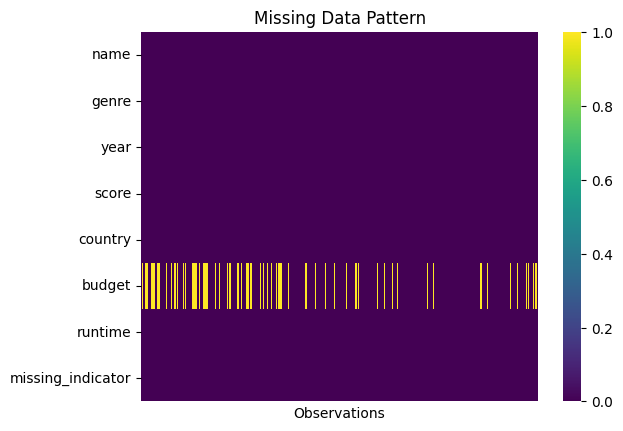

In [21]:
missing_data = hollywood_df.isnull()

ax = sns.heatmap(missing_data.T, cbar=True, cmap='viridis',
                 xticklabels=False, yticklabels=True)

ax.set_title('Missing Data Pattern')
ax.set_xlabel('Observations') #checking missing value pattern

plt.show()

<h2>Imputation Methods</h2>

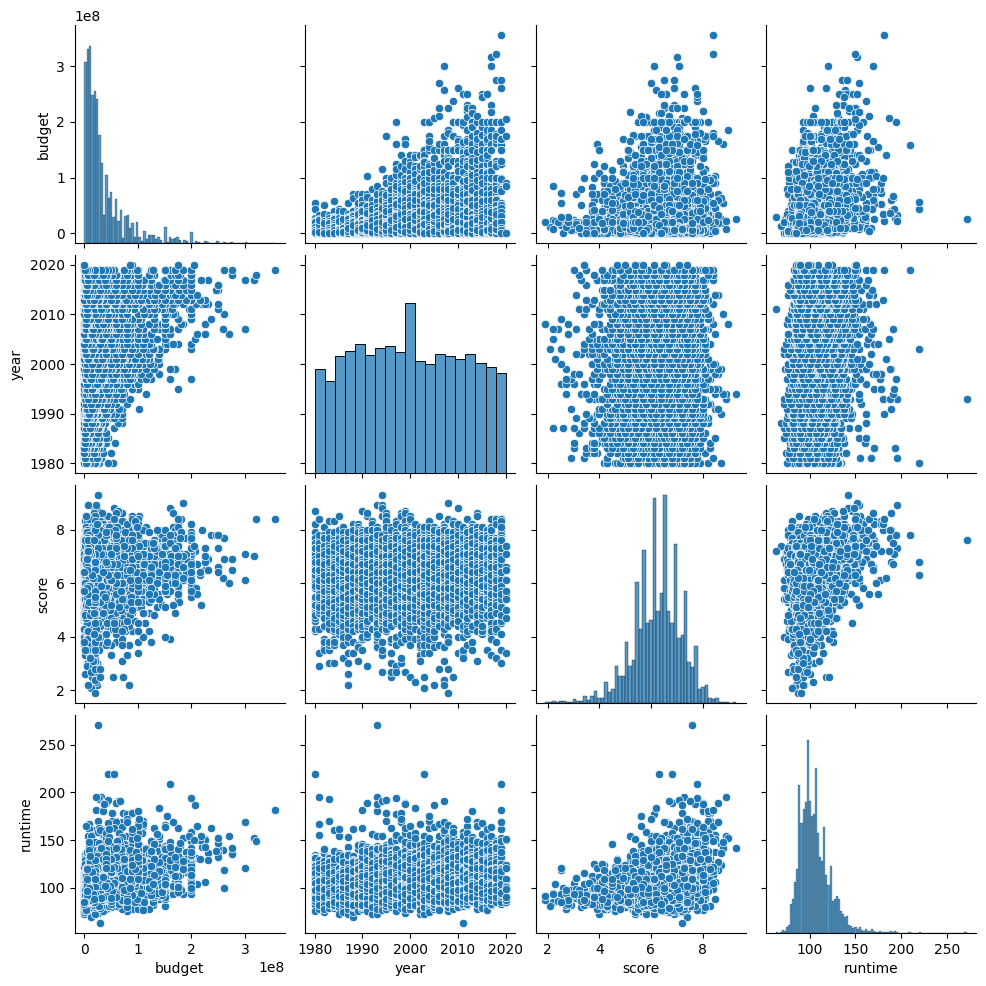

R² score: 0.2256742007524014


In [22]:

# Visual check for linearity
sns.pairplot(hollywood_df[['budget', 'year', 'score', 'runtime']])
plt.show()

# Simple linear regression check
X = hollywood_df[['year', 'score', 'runtime']].fillna(hollywood_df[['year', 'score', 'runtime']].median())
y = hollywood_df['budget'].dropna()

model = LinearRegression()
model.fit(X.loc[y.index], y)
y_pred = model.predict(X.loc[y.index])

print("R² score:", r2_score(y, y_pred))

In [23]:
hollywood_numeric = hollywood_df.select_dtypes(include=[np.number])
hollywood_numeric.columns
hollywood_object = hollywood_df.select_dtypes(include=['object'])
hollywood_object.columns

Index(['name', 'genre', 'country'], dtype='object')

In [25]:
pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 8.8 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=f3d25d143c45b5f489e250bf259ecdeb1a706273b0a4c4c5e436615c72f88a65
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=41325f6d1e262276eea8d328c39f6ab12663b28f28b7cbd99639120db4d21b34
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [30]:
hollywood_numeric.isna().sum()
len(hollywood_numeric)

5466

In [26]:
from fancyimpute import IterativeImputer

mice = IterativeImputer(random_state=0)
hollywood_imputed = mice.fit_transform(hollywood_numeric) #its preserves relationships between variables and more accurate than other imputation methods


In [31]:
hollywood_imputed_df = pd.DataFrame(hollywood_imputed, columns=hollywood_numeric.columns)

hollywood_imputed_df['budget'] = hollywood_imputed_df['budget'].astype(int)
hollywood_imputed_df.isna().sum()



,0
year,0
score,0
budget,0
runtime,0
missing_indicator,0


In [32]:
hollywood_imputed_df

,year,score,budget,runtime,missing_indicator
0,1980.0,5.8,4500000,104.0,0.0
1,1980.0,8.7,18000000,124.0,0.0
2,1980.0,7.7,3500000,88.0,0.0
3,1980.0,7.3,6000000,98.0,0.0
4,1980.0,6.4,550000,95.0,0.0
...,...,...,...,...,...
5461,2020.0,5.7,370000,85.0,0.0
5462,2020.0,5.0,37010639,120.0,1.0
5463,2020.0,3.4,37010639,87.0,1.0
5464,2020.0,7.1,37010639,90.0,1.0


In [35]:
hollywood_imputed_df.isna().sum()

,0
year,0
score,0
budget,0
runtime,0
missing_indicator,0


In [33]:
hollywood_df_modified = pd.concat([hollywood_object, hollywood_imputed_df], axis=1)
hollywood_df_modified


,name,genre,country,year,score,budget,runtime,missing_indicator
0,The Blue Lagoon,Adventure,United States,1980.0,5.8,4500000,104.0,0.0
1,Star Wars: Episode V - The Empire Strikes Back,Action,United States,1980.0,8.7,18000000,124.0,0.0
2,Airplane!,Comedy,United States,1980.0,7.7,3500000,88.0,0.0
3,Caddyshack,Comedy,United States,1980.0,7.3,6000000,98.0,0.0
4,Friday the 13th,Horror,United States,1980.0,6.4,550000,95.0,0.0
...,...,...,...,...,...,...,...,...
5461,Star Trek First Frontier,Sci-Fi,United States,2020.0,5.7,370000,85.0,0.0
5462,Tulsa,Comedy,United States,2020.0,5.0,37010639,120.0,1.0
5463,I Am Fear,Horror,United States,2020.0,3.4,37010639,87.0,1.0
5464,Aloha Surf Hotel,Comedy,United States,2020.0,7.1,37010639,90.0,1.0


In [ ]:
language = ['English'] * len(hollywood_df_modified)
Nameofwood = ['Hollywood'] * len(hollywood_df_modified) #Adding new columns 'language' and 'Industry'
hollywood_df_modified['language'] = language
hollywood_df_modified['Industry'] = Nameofwood
hollywood_df_modified.drop('country',axis=1,inplace=True)
hollywood_df_modified['runtime'] = hollywood_df_modified['runtime'].astype(int)  #converting runtime to integer type
hollywood_df_modified

,name,genre,year,score,budget,runtime,language,Industry
0,The Blue Lagoon,Adventure,1980.0,5.8,4500000,104,English,Hollywood
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980.0,8.7,18000000,124,English,Hollywood
2,Airplane!,Comedy,1980.0,7.7,3500000,88,English,Hollywood
3,Caddyshack,Comedy,1980.0,7.3,6000000,98,English,Hollywood
4,Friday the 13th,Horror,1980.0,6.4,550000,95,English,Hollywood
...,...,...,...,...,...,...,...,...
5461,Star Trek First Frontier,Sci-Fi,2020.0,5.7,370000,85,English,Hollywood
5462,Tulsa,Comedy,2020.0,5.0,37010639,120,English,Hollywood
5463,I Am Fear,Horror,2020.0,3.4,37010639,87,English,Hollywood
5464,Aloha Surf Hotel,Comedy,2020.0,7.1,37010639,90,English,Hollywood


In [ ]:
hollywood_df_modified.columns = ['Name','Genre','Year','Rating','Budget','Duration','Language','Industry'] #changing column names for better understanding
hollywood_df_modified

,Name,Genre,Year,Rating,Budget,Duration,Language,Industry
0,The Blue Lagoon,Adventure,1980.0,5.8,4500000,104,English,Hollywood
1,Star Wars: Episode V - The Empire Strikes Back,Action,1980.0,8.7,18000000,124,English,Hollywood
2,Airplane!,Comedy,1980.0,7.7,3500000,88,English,Hollywood
3,Caddyshack,Comedy,1980.0,7.3,6000000,98,English,Hollywood
4,Friday the 13th,Horror,1980.0,6.4,550000,95,English,Hollywood
...,...,...,...,...,...,...,...,...
5461,Star Trek First Frontier,Sci-Fi,2020.0,5.7,370000,85,English,Hollywood
5462,Tulsa,Comedy,2020.0,5.0,37010639,120,English,Hollywood
5463,I Am Fear,Horror,2020.0,3.4,37010639,87,English,Hollywood
5464,Aloha Surf Hotel,Comedy,2020.0,7.1,37010639,90,English,Hollywood


In [ ]:
hollywood_df_modified = hollywood_df_modified[['Name', 'Year','Genre',  'Budget', 'Duration', 'Rating', 'Language', 'Industry']] #fixing the order of columns in order to merge datasets


In [ ]:
print(hollywood_df_modified[hollywood_df_modified.duplicated(subset=['Name'], keep=False)]) #Checking for duplicate movie names


                 Name    Year      Genre     Budget  Duration  Rating  \
4     Friday the 13th  1980.0     Horror     550000        95     6.4   
14               Fame  1980.0      Drama   37010639       134     6.6   
16            The Fog  1980.0     Horror    1000000        89     6.8   
39         The Island  1980.0     Action   22000000       109     5.3   
85       Endless Love  1981.0      Drama   37010639       116     4.9   
...               ...     ...        ...        ...       ...     ...   
5344     Little Women  2019.0      Drama   40000000       135     7.8   
5364          Hellboy  2019.0     Action   50000000       120     5.2   
5370    The Lion King  2019.0  Animation  260000000       118     6.9   
5398     Pet Sematary  2019.0     Horror   21000000       101     5.7   
5401          The Kid  2019.0  Biography    8000000       100     5.9   

     Language   Industry  
4     English  Hollywood  
14    English  Hollywood  
16    English  Hollywood  
39    English  

In [ ]:
hollywood_df_modified.drop_duplicates(subset=['Name'], keep='first', inplace=True) #handling duplicate movies
hollywood_df_modified.reset_index(drop=True, inplace=True)

In [ ]:
hollywood_df_modified.duplicated().any()

False

In [ ]:
hollywood_df_modified.to_csv('Datasets/modified_hollywood_movies.csv', index=False) #saving the modified hollywood dataset